# Poisson Solver Testing - uniform Grid


## Grids Tested

**Angular grids** (fixed across all radii, shared angular mesh):

- **Uniform:**  
  Angles: $\theta_j = \frac{2\pi j}{N}, \qquad j = 0,\dots,N-1.$  


## Method Suite

Four solvers:

- **FFT** (uniform grid only): standard equispaced FFT on the uniform angular mesh, exact and fastest.
- **NUDFT**: direct nonuniform DFT on the random and clustered meshes, solved via regularized least-squares, used as a high-accuracy reference where the frame is not too ill-conditioned.
- **NUFFT (Toeplitz normal-equations):** fast nonuniform transform via FINUFFT, with Fourier coefficients recovered by a Toeplitz/Block-CG solver — a fast Toeplitz operator built from FFT–KDE density weights and a T. Chan circulant preconditioner, solved via Block CG.
- **NUFFT (unsquared PCGLS):** fast nonuniform transform via FINUFFT, with Fourier coefficients recovered by an unsquared PCGLS (Pipe & Menon–style) conjugate-gradient solver on the original normal operator, avoiding spectral squaring.



In [1]:
import os
import sys
import platform
import psutil
from pathlib import Path

# ---------------------------------------------------------
# Backend & Environment Configuration
# ---------------------------------------------------------
USE_GPU = True  # Set to True for NVIDIA GPU acceleration

# Auto-detect Google Colab & Auto-Sync
IN_COLAB = 'google.colab' in sys.modules or os.environ.get('COLAB_GPU') is not None
if IN_COLAB:
    if not os.path.exists('/content/NUFFTRR_Poisson'):
        os.system('git clone https://github.com/CharliePyle4/NUFFTRR_Poisson.git /content/NUFFTRR_Poisson')
    
    # Fetch and hard reset to latest GitHub commit
    os.system('cd /content/NUFFTRR_Poisson && git fetch origin main && git reset --hard origin/main')
    
    if os.getcwd() != '/content/NUFFTRR_Poisson':
        os.chdir('/content/NUFFTRR_Poisson')
        
    os.system('pip install -r requirements.txt -q')
    if USE_GPU:
        os.system('pip install cufinufft -q')

# Dynamic repository root and helper path resolution
repo_root = str(Path.cwd().resolve())
while repo_root and not os.path.exists(os.path.join(repo_root, 'Poisson_Solver')):
    parent = str(Path(repo_root).parent)
    if parent == repo_root:
        break
    repo_root = parent
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

tests_dir = os.path.join(repo_root, 'Tests', 'paper')
if tests_dir not in sys.path:
    sys.path.insert(0, tests_dir)

# Solver Parameters
# Solver Parameters (Uniform Grid)
num_processors = None  # Number of CPU threads (None = all available cores)
maxiter_nufft = 100    # Maximum CG iterations
tol_nufft = 1e-10      # CG residual tolerance for NUFFT
reg_param = 1e-20      # Regularization parameter
eps_finufft = 1e-12    # FINUFFT kernel precision

from uniform_testing_helpers import *

# Multi-Run Benchmark Timing Configuration
TIME_TRIALS = True  # Set to True to run each test 5 times and record min runtime
NUM_RUNS = 5 if TIME_TRIALS else 1

set_timing_config(time_trials=TIME_TRIALS, num_runs=NUM_RUNS, use_gpu=USE_GPU)

# ---------------------------------------------------------
# System & Hardware Diagnostics Banner
# ---------------------------------------------------------
ram_gb = psutil.virtual_memory().total / (1024 ** 3)
ram_avail_gb = psutil.virtual_memory().available / (1024 ** 3)
cpu_cores_logical = os.cpu_count()
cpu_cores_phys = psutil.cpu_count(logical=False)
cpu_model = platform.processor() or "Generic CPU"
if IN_COLAB and os.path.exists('/proc/cpuinfo'):
    with open('/proc/cpuinfo') as f:
        for line in f:
            if "model name" in line:
                cpu_model = line.split(":", 1)[1].strip()
                break

backend_name = 'GPU (NVIDIA CuPy / cuFFT)' if USE_GPU else 'CPU (Multithreaded FINUFFT)'

print('=' * 75)
print(f'  BENCHMARK ENVIRONMENT SUMMARY')
print('=' * 75)
print(f'  Active Backend  : {backend_name}')
print(f'  Environment     : {"Google Colab" if IN_COLAB else "Local Workstation"} ({platform.system()} {platform.release()})')
print(f'  Host CPU        : {cpu_model}')
print(f'  CPU Cores       : {cpu_cores_phys} Physical / {cpu_cores_logical} Logical Threads')
print(f'  System RAM      : {ram_gb:.1f} GB Total ({ram_avail_gb:.1f} GB Available)')

if USE_GPU:
    try:
        import cupy as cp
        dev = cp.cuda.Device()
        props = cp.cuda.runtime.getDeviceProperties(dev.id)
        gpu_name = props['name'].decode('utf-8') if isinstance(props['name'], bytes) else str(props['name'])
        compute_cap = f"{props['major']}.{props['minor']}"
        free_mem_gb, total_mem_gb = dev.mem_info[0] / (1024**3), dev.mem_info[1] / (1024**3)
        
        print('-' * 75)
        print(f'  GPU Device      : {gpu_name} (Compute Capability: {compute_cap})')
        print(f'  GPU VRAM        : {total_mem_gb:.1f} GB Total ({free_mem_gb:.1f} GB Free)')
        print(f'  CUDA Driver/RT  : {cp.cuda.runtime.runtimeGetVersion()}')
    except Exception as e:
        print(f'  GPU Status      : Warning - GPU query failed: {e}')

print(f'  Time Trials     : {TIME_TRIALS} (Runs = {NUM_RUNS})')
print('=' * 75)


c:\Users\charl\miniconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Setup & Configurable Parameters

In [2]:
# =============================================================================
# Domain & Solver Parameters
# =============================================================================
R = 1.0                     # Disk radius
RAD_UNIF = 1                # 1: Uniform radial grid
RADIAL_MAPPING = None       # Non-uniform radial mapping if RAD_UNIF == 0
# Solver Tolerances & Regularization (Lambda)
TOL_NUFFT = 1e-10           # CG residual tolerance for NUFFT
MAXITER_NUFFT = 100         # Maximum CG iterations (50-100 is optimal)
EPS_FINUFFT = 1e-12         # FINUFFT kernel precision (optimal W=10 width)
REG_PARAM = 1e-20           # Regularization parameter
QUAD_RULE = 1               # 1: Trapezoidal, 2: Simpson's rule
BC_CHOICE = 1               # 1: Dirichlet, 2: Neumann


# =============================================================================
# Problem Selection
# =============================================================================
PROBLEM_TYPE = 0            # 0: Borges & Daripa Problem 1, 2: Problem 2
CUSTOM_PROBLEM = None
# Apply global configuration
set_global_config(
    R=R,
    rad_unif=RAD_UNIF,
    radial_mapping=RADIAL_MAPPING,
    tol_nufft=TOL_NUFFT,
    maxiter_nufft=MAXITER_NUFFT,
    eps_finufft=EPS_FINUFFT,
    reg_param=REG_PARAM,
    quad_rule=QUAD_RULE,
    BC_choice=BC_CHOICE,
    problem_type=PROBLEM_TYPE,
    custom_problem=CUSTOM_PROBLEM,
    num_processors=num_processors,
    use_gpu=USE_GPU,
    time_trials=TIME_TRIALS,
    num_runs=NUM_RUNS,
)

# =============================================================================
# Grid Sweep Resolutions
# =============================================================================
N_vals_p1 = [32, 64, 128, 256, 512 , 1024, 2048]
M_vals_p1 = [32, 64, 128, 256, 512, 1024, 2048]
N_fixed_p1 = 128


N_vals_c = [32, 64, 128, 256, 512]
M_vals_c = [32, 64, 128, 256, 512]
N_fixed_c = 128
M_fixed_c = 128

MUTE_OUTPUT = True


# Run Problems

In [3]:
# -----------------------------------------------------------------------------
# Methods for Problem 1 Single-Grid Tables (Using Pure Random Grid as the example)
# -----------------------------------------------------------------------------
METHODS_p1 = [
    dict(
        name="Unif-FFT",
        label="Uniform / FFT",
        azu_unif=2,             # uniform azimuthal grid
        mesh_kind="uniform",
        solver_azu_unif=2,      # FFT-based solver
        use_nudft=None,
    ),
    dict(
        name="Unif-NUDFT",
        label="Uniform / NUDFT",
        azu_unif=2,
        mesh_kind="uniform",
        solver_azu_unif=1,      # NUDFT analysis on uniform nodes
        use_nudft=True,
    ),
    dict(
        name="Unif-NUFFT-Toeplitz",
        label="Uniform / NUFFT (Toeplitz)",
        azu_unif=2,
        mesh_kind="uniform",
        solver_azu_unif=1,
        grid_type=2,            # Toeplitz/block–CG path
        use_nudft=False,
    ),
    dict(
        name="Unif-NUFFT-Unsquared",
        label="Uniform / NUFFT (Unsquared)",
        azu_unif=2,
        mesh_kind="uniform",
        solver_azu_unif=1,
        grid_type=3,            # unsquared PCGLS path
        use_nudft=False,
    ),
]

METHODS_COMP = [
    dict(
        name="Unif-FFT",
        label="Uniform / FFT",
        azu_unif=2,
        mesh_kind="uniform",
        solver_azu_unif=2,
        use_nudft=None,
    ),
    dict(
        name="Unif-NUDFT",
        label="Uniform / NUDFT",
        azu_unif=2,
        mesh_kind="uniform",
        solver_azu_unif=1,
        use_nudft=True,
    ),
    dict(
        name="Unif-NUFFT-Toeplitz",
        label="Uniform / NUFFT (Toeplitz)",
        azu_unif=2,
        mesh_kind="uniform",
        solver_azu_unif=1,
        grid_type=2,
        use_nudft=False,
    ),
    dict(
        name="Unif-NUFFT-Unsquared",
        label="Uniform / NUFFT (Unsquared)",
        azu_unif=2,
        mesh_kind="uniform",
        solver_azu_unif=1,
        grid_type=3,
        use_nudft=False,
    ),
]


print("\nRunning Problem 1 - Table 1 (uniform Grid)...")
df_p1_t1 = run_tests_pipeline(N_vals_p1, M_vals_p1, fixed_other=None, methods=METHODS_p1, test_type="P1_Table1", mute=MUTE_OUTPUT, num_processors=num_processors, use_gpu=USE_GPU, time_trials=TIME_TRIALS, num_runs=NUM_RUNS, maxiter_nufft=MAXITER_NUFFT, tol_nufft=TOL_NUFFT, reg_param=REG_PARAM, eps_finufft=EPS_FINUFFT)
print("\nRunning Problem 1 - Table 2 (uniform Grid)...")
df_p1_t2 = run_tests_pipeline(None, M_vals_p1, fixed_other=N_fixed_p1, methods=METHODS_p1, test_type="P1_Table2", mute=MUTE_OUTPUT, num_processors=num_processors, use_gpu=USE_GPU, time_trials=TIME_TRIALS, num_runs=NUM_RUNS, maxiter_nufft=MAXITER_NUFFT, tol_nufft=TOL_NUFFT, reg_param=REG_PARAM, eps_finufft=EPS_FINUFFT)

print("\nRunning Accuracy Comparisons...")
df_cN = run_tests_pipeline(
    N_vals_c, None,
    fixed_other=M_fixed_c,
    methods=METHODS_COMP,
    test_type="Accuracy_VaryN",
    mute=MUTE_OUTPUT,
    num_processors=num_processors,
    use_gpu=USE_GPU,
    time_trials=TIME_TRIALS,
    num_runs=NUM_RUNS,
    maxiter_nufft=MAXITER_NUFFT,
    tol_nufft=TOL_NUFFT,
    reg_param=REG_PARAM,
    eps_finufft=EPS_FINUFFT,
)
df_cM = run_tests_pipeline(
    None, M_vals_c,
    fixed_other=N_fixed_c,
    methods=METHODS_COMP,
    test_type="Accuracy_VaryM",
    mute=MUTE_OUTPUT,
    num_processors=num_processors,
    use_gpu=USE_GPU,
    time_trials=TIME_TRIALS,
    num_runs=NUM_RUNS,
    maxiter_nufft=MAXITER_NUFFT,
    tol_nufft=TOL_NUFFT,
    reg_param=REG_PARAM,
    eps_finufft=EPS_FINUFFT,
)
print("Done.")



Running Problem 1 - Table 1 (uniform Grid)...


Pipeline (P1_Table1): 100%|██████████| 4/4 [02:30<00:00, 37.68s/it, method=Unif-NUFFT-Unsquared]



Running Problem 1 - Table 2 (uniform Grid)...


Pipeline (P1_Table2): 100%|██████████| 4/4 [00:24<00:00,  6.06s/it, method=Unif-NUFFT-Unsquared]



Running Accuracy Comparisons...


Pipeline (Accuracy_VaryM): 100%|██████████| 4/4 [00:01<00:00,  2.16it/s, method=Unif-NUFFT-Unsquared]

Done.


# Accuracy across Meshes

Varying N on the uniform grid — errors should decay rapidly with N for all solvers, with FFT providing the reference.

Accuracy Comparison (Fixed M=128) Accuracy


label,Uniform / FFT,Uniform / NUDFT,Uniform / NUFFT (Toeplitz),Uniform / NUFFT (Unsquared)
N,,,,
32,6.55e-07,6.55e-07,6.55e-07,6.55e-07
64,6.55e-07,6.55e-07,6.55e-07,6.55e-07
128,6.55e-07,6.55e-07,6.55e-07,6.55e-07
256,6.55e-07,6.55e-07,6.55e-07,6.55e-07
512,6.55e-07,6.55e-07,6.55e-07,6.55e-07


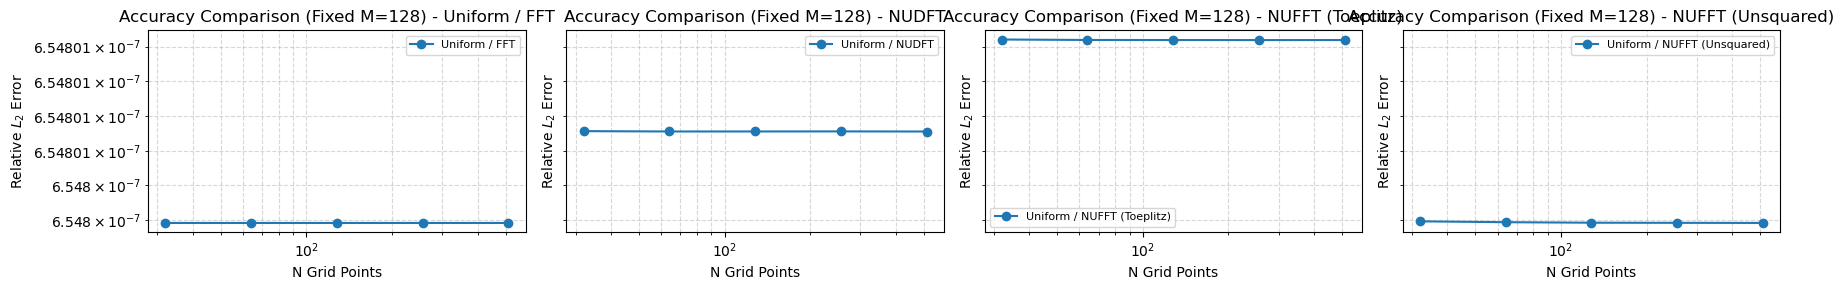

These plots compare NUDFT and the two NUFFT variants against FFT on the uniform azimuthal mesh.
Varying M on the uniform grid — for fixed N, errors should decrease as M increases, reflecting radial convergence.

Accuracy Comparison (Fixed N=128) Accuracy


label,Uniform / FFT,Uniform / NUDFT,Uniform / NUFFT (Toeplitz),Uniform / NUFFT (Unsquared)
M,,,,
32,1.10e-05,1.10e-05,1.10e-05,1.10e-05
64,2.66e-06,2.66e-06,2.66e-06,2.66e-06
128,6.55e-07,6.55e-07,6.55e-07,6.55e-07
256,1.62e-07,1.62e-07,1.62e-07,1.62e-07
512,4.04e-08,4.04e-08,4.04e-08,4.04e-08


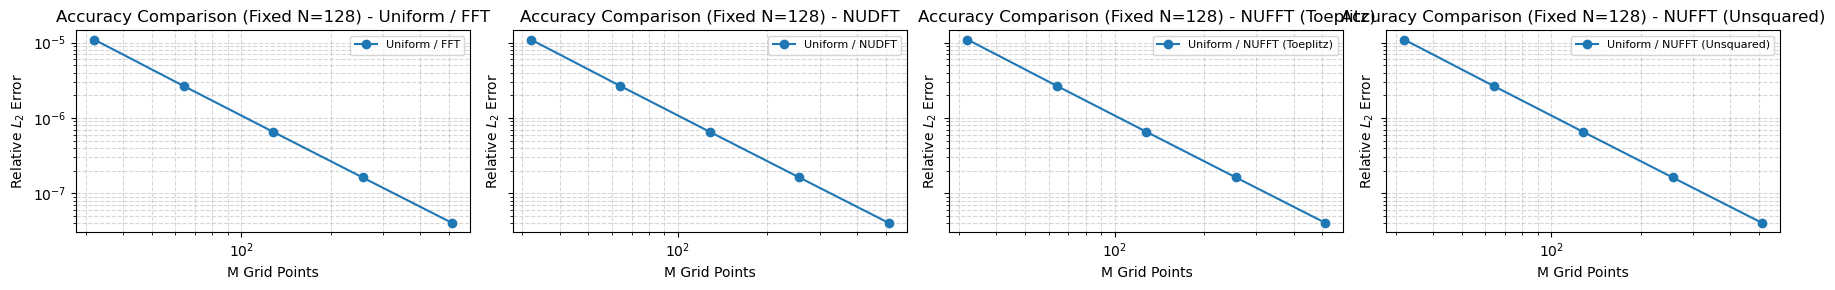

Differences between solvers show how sensitive each algorithm is to radial refinement on the uniform grid.


In [4]:
print("Varying N on the uniform grid — errors should decay rapidly with N for all solvers, with FFT providing the reference.")
render_accuracy(
    df_cN,
    index_col="N",
    columns_col="label",
    title_prefix=f"Accuracy Comparison (Fixed M={M_fixed_c})"
)
plot_accuracy_comparison(
    df_cN,
    index_col="N",
    title_prefix=f"Accuracy Comparison (Fixed M={M_fixed_c})"
)
print("These plots compare NUDFT and the two NUFFT variants against FFT on the uniform azimuthal mesh.")

print("Varying M on the uniform grid — for fixed N, errors should decrease as M increases, reflecting radial convergence.")
render_accuracy(
    df_cM,
    index_col="M",
    columns_col="label",
    title_prefix=f"Accuracy Comparison (Fixed N={N_fixed_c})"
)
plot_accuracy_comparison(
    df_cM,
    index_col="M",
    title_prefix=f"Accuracy Comparison (Fixed N={N_fixed_c})"
)
print("Differences between solvers show how sensitive each algorithm is to radial refinement on the uniform grid.")

# Accuracy for uniform grid

Problem 1 — Table 1: Relative L2 error over angular and radial resolutions (pure uniform grid)

Problem 1 — Table 1 Accuracy


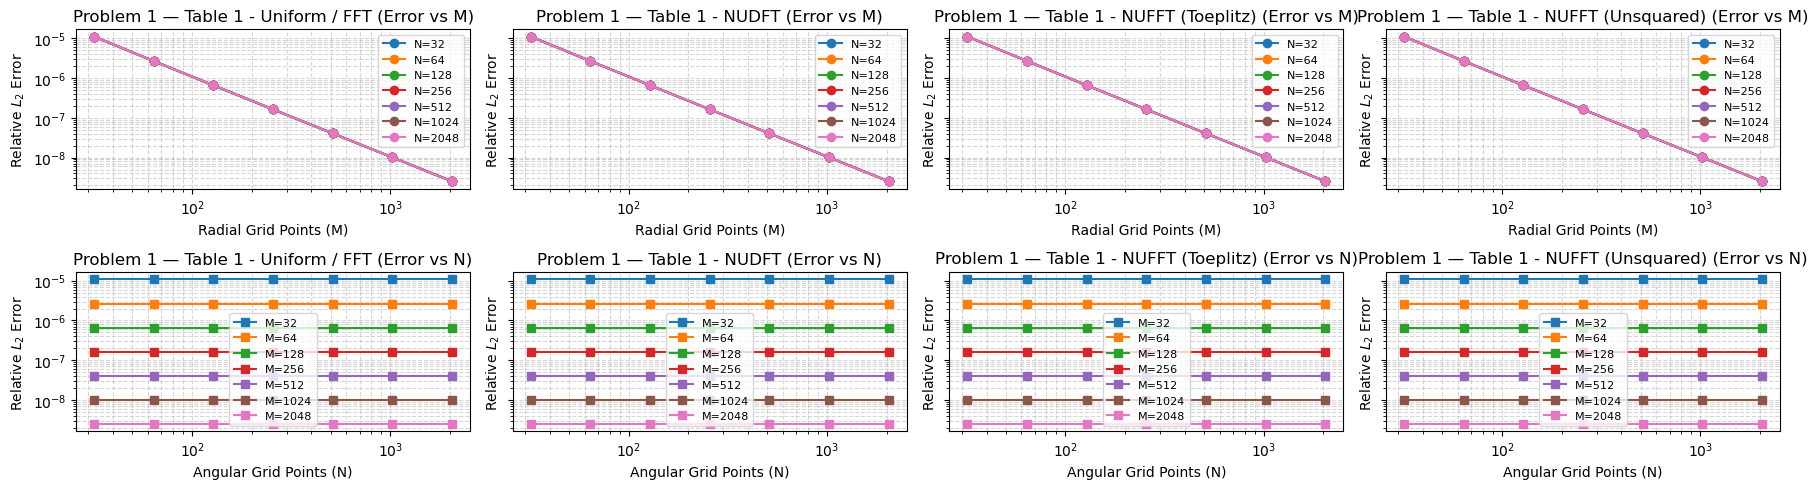

Problem 1 — Table 2: Relative L2 error by quadrature rule and boundary condition (N=128, pure uniform grid)

Problem 1 — Table 2 (N=128) Accuracy


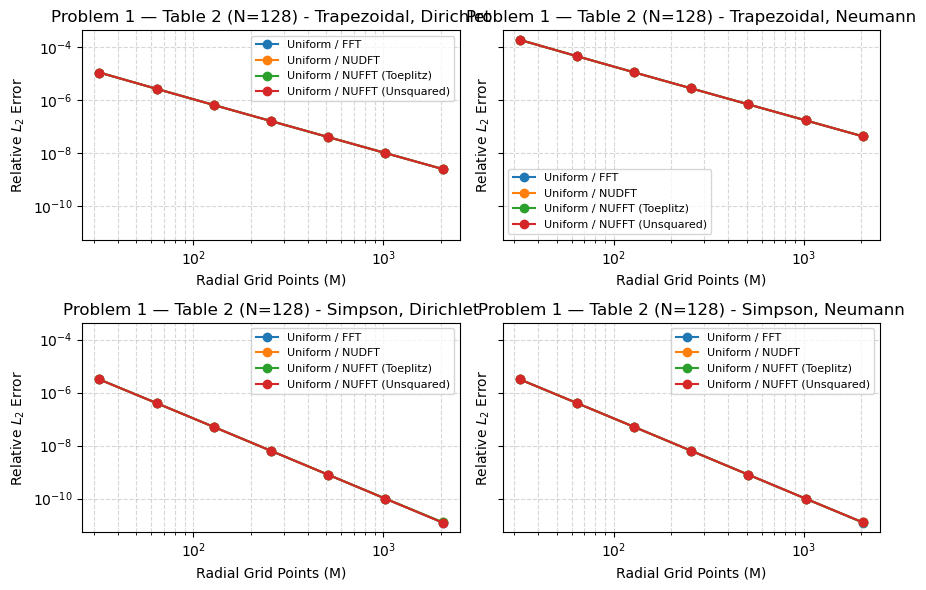

In [5]:
# Accuracy for completely uniform grid (Problem 1)
print("Problem 1 — Table 1: Relative L2 error over angular and radial resolutions (pure uniform grid)")
render_accuracy(df_p1_t1, index_col="N", columns_col=["label", "M"], title_prefix="Problem 1 — Table 1")
plot_accuracy_table1(df_p1_t1, title_prefix="Problem 1 — Table 1")

print(f"Problem 1 — Table 2: Relative L2 error by quadrature rule and boundary condition (N={N_fixed_p1}, pure uniform grid)")
render_table2_accuracy(df_p1_t2, title_prefix=f"Problem 1 — Table 2 (N={N_fixed_p1})")
plot_accuracy_table2(df_p1_t2, title_prefix=f"Problem 1 — Table 2 (N={N_fixed_p1})")

# Runtimes

Problem 1 — Table 1: Runtimes (pure uniform angular grid)

Problem 1 — Table 1 Runtime (s)


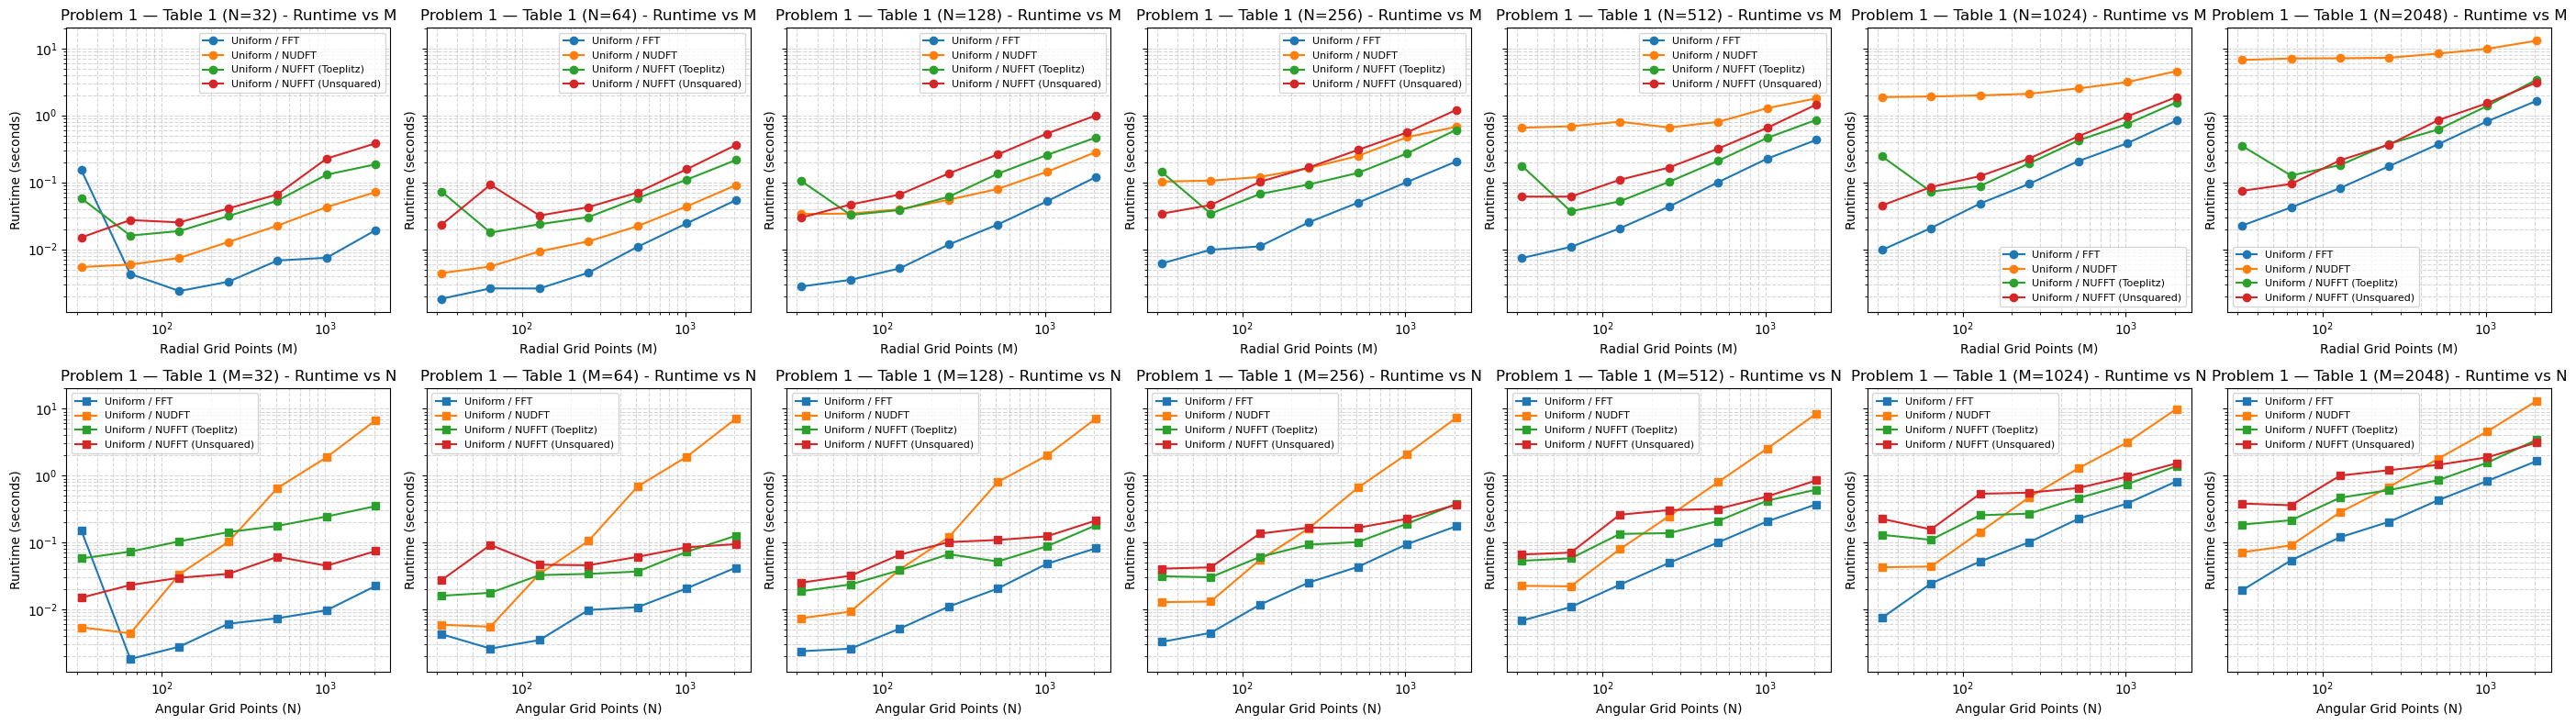

Problem 1 — Table 2: Runtimes (pure uniform angular grid, N=128)

Problem 1 — Table 2 (N=128) Runtime (s)


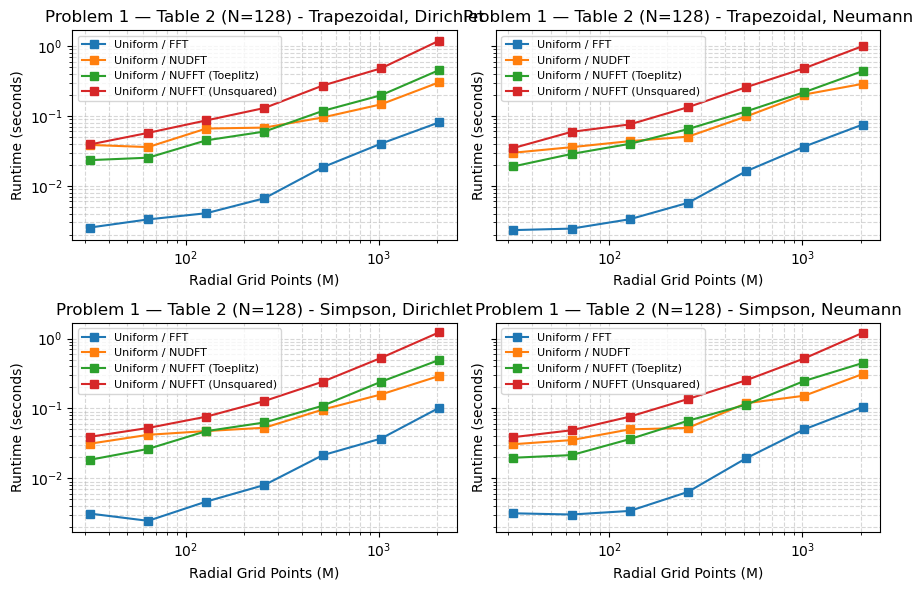

Accuracy Comparison (Fixed M=128) Runtimes

Accuracy Comparison (Fixed M=128) Runtime (s)


label,Uniform / FFT,Uniform / NUDFT,Uniform / NUFFT (Toeplitz),Uniform / NUFFT (Unsquared)
N,,,,
32,0.0031,0.0078,0.0220,0.0341
64,0.0038,0.0090,0.0813,0.0365
128,0.0045,0.0427,0.0379,0.0933
256,0.0076,0.1740,0.0483,0.0850
512,0.0203,0.8110,0.0659,0.1043


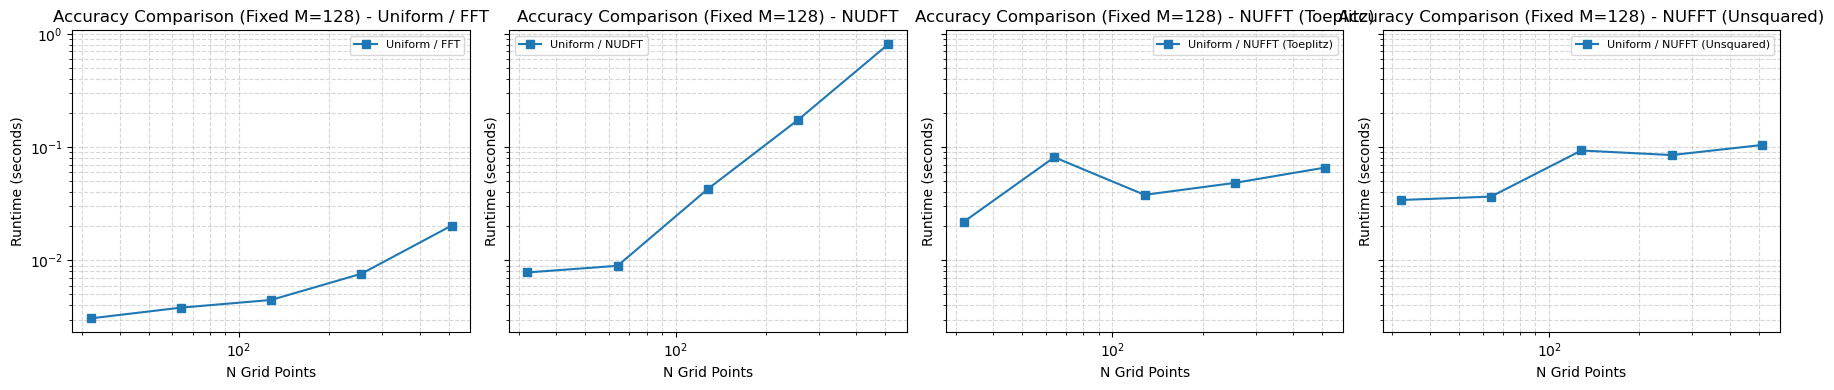

Accuracy Comparison (Fixed N=128) Runtimes

Accuracy Comparison (Fixed N=128) Runtime (s)


label,Uniform / FFT,Uniform / NUDFT,Uniform / NUFFT (Toeplitz),Uniform / NUFFT (Unsquared)
M,,,,
32,0.0026,0.0782,0.0247,0.0389
64,0.0040,0.0632,0.0319,0.0506
128,0.0048,0.0556,0.0423,0.0823
256,0.0069,0.0764,0.0649,0.1630
512,0.0185,0.1211,0.1478,0.2635


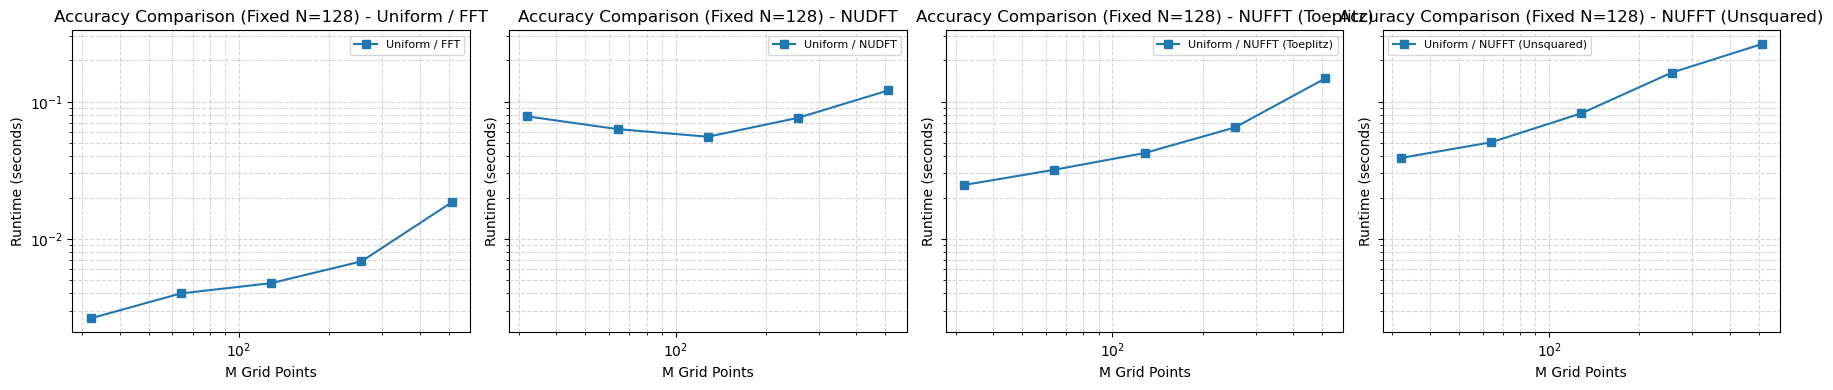

In [6]:

print("Problem 1 — Table 1: Runtimes (pure uniform angular grid)")
render_runtime(df_p1_t1, index_col="N", columns_col=["label", "M"], title_prefix="Problem 1 — Table 1")
plot_runtime_table1(df_p1_t1, title_prefix="Problem 1 — Table 1")

print(f"Problem 1 — Table 2: Runtimes (pure uniform angular grid, N={N_fixed_p1})")
render_table2_runtime(df_p1_t2, title_prefix=f"Problem 1 — Table 2 (N={N_fixed_p1})")
plot_runtime_table2(df_p1_t2, title_prefix=f"Problem 1 — Table 2 (N={N_fixed_p1})")


print(f"Accuracy Comparison (Fixed M={M_fixed_c}) Runtimes")
render_runtime(
    df_cN,
    index_col="N",
    columns_col="label",
    title_prefix=f"Accuracy Comparison (Fixed M={M_fixed_c})"
)
plot_runtime_comparison(
    df_cN,
    index_col="N",
    title_prefix=f"Accuracy Comparison (Fixed M={M_fixed_c})"
)

print(f"Accuracy Comparison (Fixed N={N_fixed_c}) Runtimes")
render_runtime(
    df_cM,
    index_col="M",
    columns_col="label",
    title_prefix=f"Accuracy Comparison (Fixed N={N_fixed_c})"
)
plot_runtime_comparison(
    df_cM,
    index_col="M",
    title_prefix=f"Accuracy Comparison (Fixed N={N_fixed_c})"
)

# for paper

Problem 1 — Table 1: Runtimes (pure uniform angular grid)

Problem 1 — Table 1 Runtime (s)


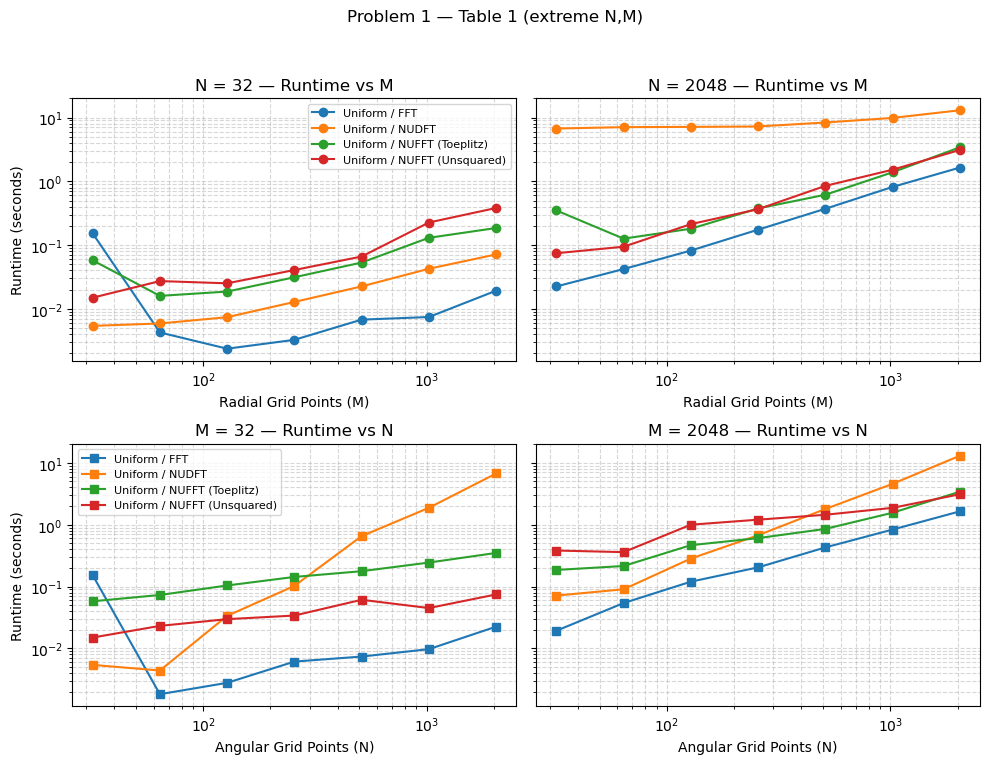

In [7]:
from Tests.CPU.testing_helpers import plot_runtime_table1_extremes



print("Problem 1 — Table 1: Runtimes (pure uniform angular grid)")
render_runtime(df_p1_t1, index_col="N", columns_col=["label", "M"],
               title_prefix="Problem 1 — Table 1")

plot_runtime_table1_extremes(df_p1_t1,
                             title_prefix="Problem 1 — Table 1 (extreme N,M)")

